# Solving the 2-D Poisson Equation with the SOR Method

**Methods:** Successive Over-Relaxation (SOR) iterative solver, NumPy, Matplotlib

### Overview
This notebook solves an elliptic Poisson equation for the equilibrium field and examines dependence on the source parameter $\rho$/T and the relaxation factor $\omega$.

----

#### Why for-loops are used instead of NumPy operations

NumPy operations update multiple grid points simultaneously. For example, an operation such as `np.roll` shifts an entire row or column at the same time. However, the SOR algorithm requires sequential updates because each value, `T[j, i]`, depends on its neighboring grid points, including values that may have already been updated during the current iteration.

Using a vectorized NumPy operation would update all values simultaneously and overwrite the intermediate values required for the sequential calculation. Therefore, for-loops are used to update each element individually and preserve the update order required by the SOR algorithm.

#### Effect of `RhoT` on the Equilibrium State

Let's start by solving the following elliptical equation:

\begin{align}
\frac{\partial^2 T}{\partial x^2}+\frac{\partial^2 T}{\partial y^2}=g\frac{\rho}{T}
\end{align}

with the following finite difference method (centered-in-space) assuming $\Delta x=\Delta y$.

\begin{align}
\frac{T_{i+1,j}-2T_{i,j}+T_{i-1,j}}{\Delta x^2}+\frac{T_{i,j+1}-2T_{i,j}+T_{i,j-1}}{\Delta y^2}&=g\frac{\rho}{T} \\
T_{i+1,j}+T_{i-1,j}+T_{i,j+1}+T_{i,j-1}-4T_{i,j}&=\Delta x^2g\frac{\rho}{T}
\end{align}

further rearranging the above equation,

\begin{align}
T_{i,j} = \frac{1}{4}(T_{i+1,j}+T_{i-1,j}+T_{i,j+1}+T_{i,j-1}+\Delta x^2g\frac{\rho}{T})
\end{align}

**Procedure:**

1. Set $k$ number of iterations.
2. Calculate the residual $R^{k}$ for each iteration loop as follows:

\begin{align}
R^{k}_{i,j}&=\frac{1}{4}(T^k_{i+1,j}+T^{k+1}_{i-1,j}+T^k_{i,j+1}+T^{k+1}_{i,j-1}-\Delta x^2g\frac{\rho}{T})-T^k_{i,j}
\end{align}

3. Conduct the adjustments for $T_{i,j}$ for $k+1$-th iteration:

\begin{align}
T^{k+1}_{i,j} = T^{k}_{i,j}+\omega R^{k}_{i,j}
\end{align}

---

#### Import necessary library and create functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_rhot(ax, data, rhot, w, vmin, vmax, nk):
  data = np.copy(data)
  for k in range(0,nk):
    for j in range(1,grid_y-1):
        for i in range(1,grid_x-1):
            R = 0.25*(data[j,i+1]+data[j,i-1]+data[j+1,i]+data[j-1,i]-g*rhot*dx**2.)
            data[j,i] = (1-w)*data[j,i]+w*R
  #plt.contourf(x,y,data,cmap='rainbow',levels=np.linspace(np.min(data),np.max(data),30))
  pixel_plot = ax.imshow(data, cmap='nipy_spectral', interpolation='nearest', vmin=vmin, vmax=vmax)
  fig = ax.get_figure()
  fig.colorbar(pixel_plot, ax=ax, shrink=0.5, aspect=5)
  ax.set_title(f'RhoT at : {rhot:.5f}' + f' k = {k}' + f' w = {w}')
  ax.set_xlabel('X-axis')
  ax.set_ylabel('Y-axis')

Define necessary inputs

In [2]:
g = 9.81
#RhoT = 0.001 #Corresponds to Rho over T from the equation above.
dx = dy = 1.
len_x = 100.
len_y = 100.
grid_x = int(len_x/dx)
grid_y = int(len_y/dy)

x = np.linspace(0.,grid_x*dx,grid_x)
y = np.linspace(0.,grid_y*dy,grid_y)

T = np.zeros((grid_y,grid_x))
T[:,0] = 0.
T[:,-1] = 0.
T[0,:] = 0.
T[-1,:] = 0.
T[0,25:75] = 50.
#w = 1.9 #Corresponding to omega in the SOR algorithm.
#nk = 1000

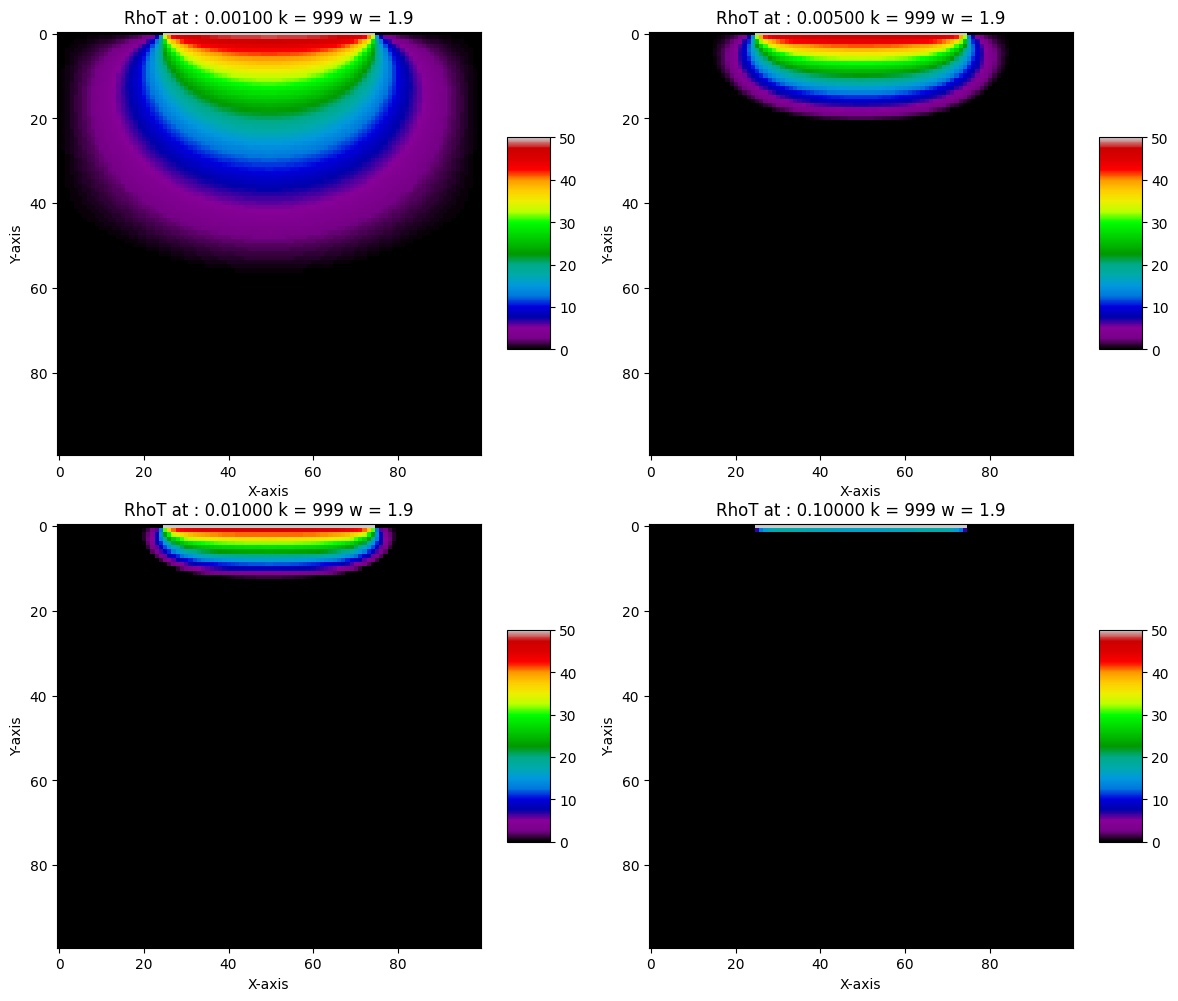

In [3]:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)
visualize_rhot(ax1, T, 0.001, 1.9, vmin=0, vmax=50, nk=1000)

T = np.zeros((grid_y,grid_x))
T[:,0] = 0.
T[:,-1] = 0.
T[0,:] = 0.
T[-1,:] = 0.
T[0,25:75] = 50.
visualize_rhot(ax2, T, 0.005, 1.9, vmin=0, vmax=50, nk=1000)

T = np.zeros((grid_y,grid_x))
T[:,0] = 0.
T[:,-1] = 0.
T[0,:] = 0.
T[-1,:] = 0.
T[0,25:75] = 50.
visualize_rhot(ax3, T, 0.01, 1.9, vmin=0, vmax=50, nk=1000)

T = np.zeros((grid_y,grid_x))
T[:,0] = 0.
T[:,-1] = 0.
T[0,:] = 0.
T[-1,:] = 0.
T[0,25:75] = 50.
visualize_rhot(ax4, T, 0.1, 1.9, vmin=0, vmax=50, nk=1000)
plt.tight_layout()
plt.show()
plt.close(fig)

As `RhoT` increases, the strength of the source term in the equation also increases. This causes the potential field to become more concentrated near the source region, resulting in a steeper gradient and a more localized equilibrium distribution. The source doesn't spread further, i.e.,  the equilibrium state becomes more localized to the source.

#### Effect of Relaxation Parameter `w` on the Equilibrium State

The resulting equilibrium values are compared to observe the effect of changing `w`.


We can use same function as previous part

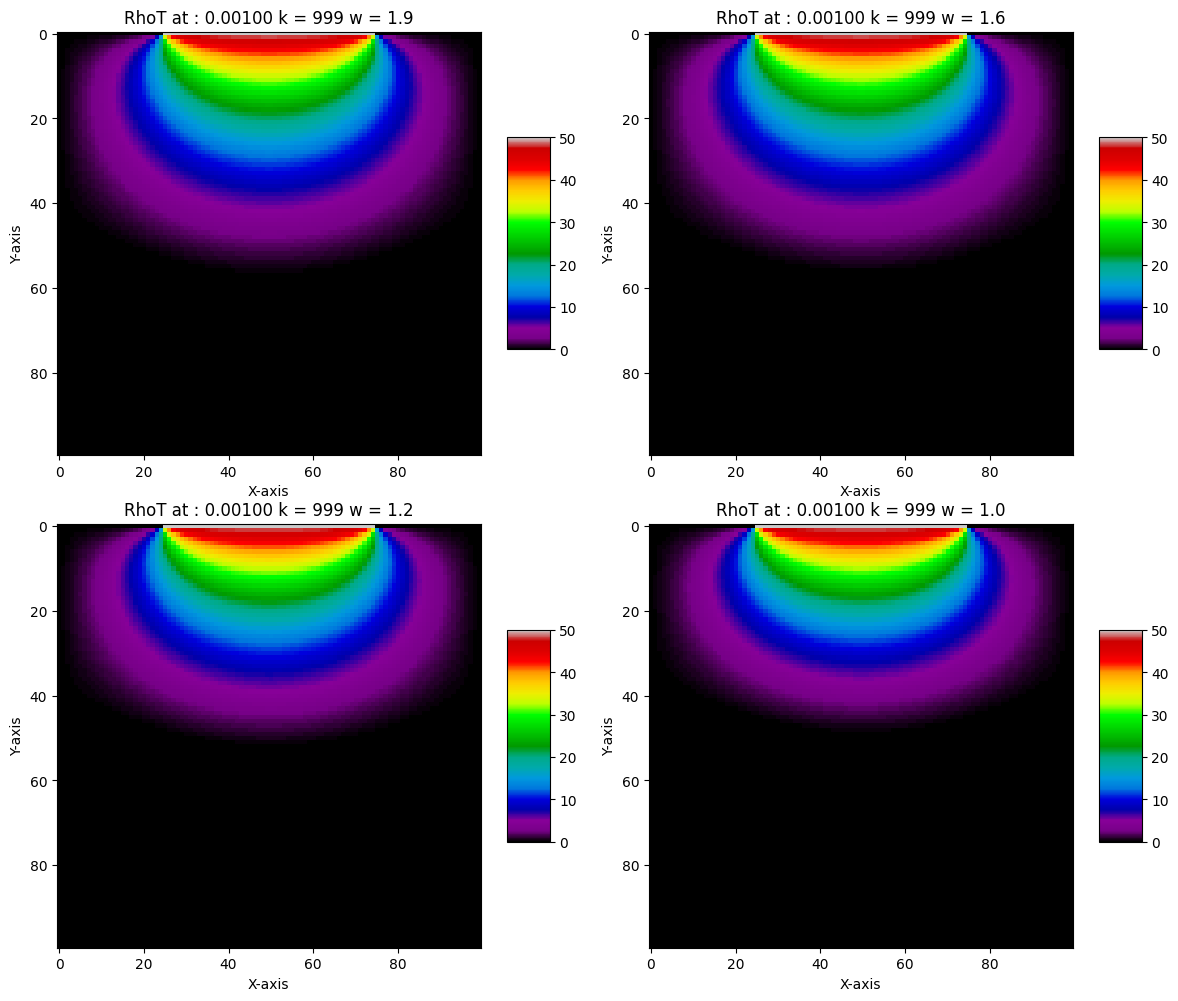

In [4]:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)
visualize_rhot(ax1, T, 0.001, 1.9, vmin=0, vmax=50, nk=1000)

T = np.zeros((grid_y,grid_x))
T[:,0] = 0.
T[:,-1] = 0.
T[0,:] = 0.
T[-1,:] = 0.
T[0,25:75] = 50.
visualize_rhot(ax2, T, 0.001, 1.6, vmin=0, vmax=50, nk=1000)

T = np.zeros((grid_y,grid_x))
T[:,0] = 0.
T[:,-1] = 0.
T[0,:] = 0.
T[-1,:] = 0.
T[0,25:75] = 50.
visualize_rhot(ax3, T, 0.001, 1.2, vmin=0, vmax=50, nk=1000)

T = np.zeros((grid_y,grid_x))
T[:,0] = 0.
T[:,-1] = 0.
T[0,:] = 0.
T[-1,:] = 0.
T[0,25:75] = 50.
visualize_rhot(ax4, T, 0.001, 1.0, vmin=0, vmax=50, nk=1000)
plt.tight_layout()
plt.show()
plt.close(fig)

Although the final equilibrium pattern looks similar, omega affects how quickly we reach that state. Small omega will converges slowly. As omega increases toward 2.0, convergence accelerates. However, if omega is too close to 2, it may diverge.

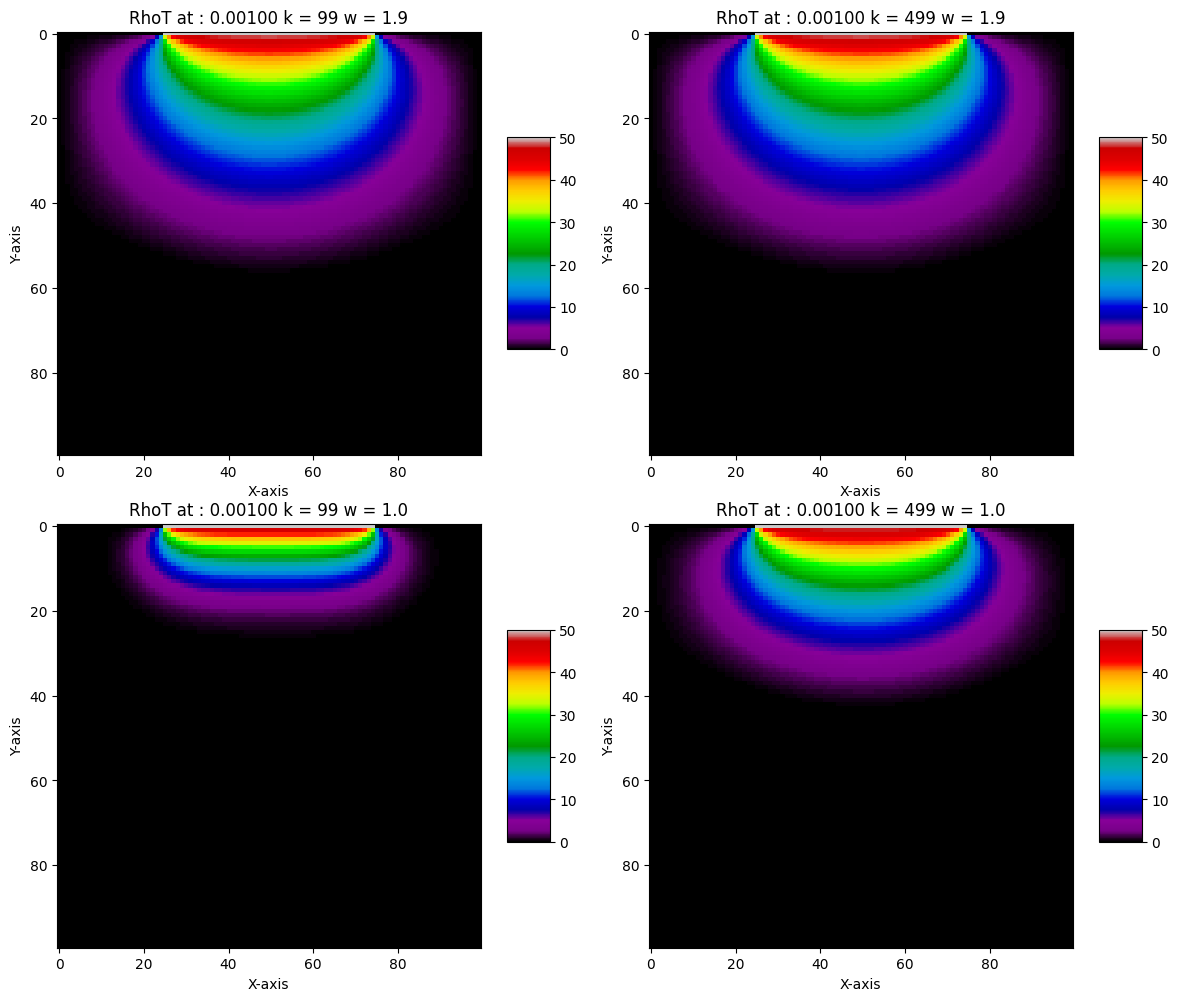

In [5]:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)
visualize_rhot(ax1, T, 0.001, 1.9, vmin=0, vmax=50, nk=100)

T = np.zeros((grid_y,grid_x))
T[:,0] = 0.
T[:,-1] = 0.
T[0,:] = 0.
T[-1,:] = 0.
T[0,25:75] = 50.
visualize_rhot(ax2, T, 0.001, 1.9, vmin=0, vmax=50, nk=500)

T = np.zeros((grid_y,grid_x))
T[:,0] = 0.
T[:,-1] = 0.
T[0,:] = 0.
T[-1,:] = 0.
T[0,25:75] = 50.
visualize_rhot(ax3, T, 0.001, 1.0, vmin=0, vmax=50, nk=100)

T = np.zeros((grid_y,grid_x))
T[:,0] = 0.
T[:,-1] = 0.
T[0,:] = 0.
T[-1,:] = 0.
T[0,25:75] = 50.
visualize_rhot(ax4, T, 0.001, 1.0, vmin=0, vmax=50, nk=500)
plt.tight_layout()
plt.show()
plt.close(fig)

As you can see, the left and right sides of the above graph show the conditions at k = 99 and 499, respectively. This clearly illustrates that the omega = 1.9 case (1st line graph) reaches equilibrium faster than the omega = 1.0 case (2nd line graph).